In [ ]:
!wget https://cs.stanford.edu/people/alecmgo/trainingandtestdata.zip
!unzip trainingandtestdata.zip
!mv training.1600000.processed.noemoticon.csv sentiment140.csv

--2025-12-19 15:03:47--  https://cs.stanford.edu/people/alecmgo/trainingandtestdata.zip
Resolving cs.stanford.edu (cs.stanford.edu)... 171.64.64.64
Connecting to cs.stanford.edu (cs.stanford.edu)|171.64.64.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 81363704 (78M) [application/zip]
Saving to: ‘trainingandtestdata.zip’

trainingandtestdata 100%[===================>]  77.59M  39.8MB/s    in 1.9s    

2025-12-19 15:03:50 (39.8 MB/s) - ‘trainingandtestdata.zip’ saved [81363704/81363704]

Archive:  trainingandtestdata.zip
  inflating: testdata.manual.2009.06.14.csv  
  inflating: training.1600000.processed.noemoticon.csv  


In [ ]:
!mv training.1600000.processed.noemoticon.csv sentiment140.csv

mv: cannot stat 'training.1600000.processed.noemoticon.csv': No such file or directory


In [ ]:
!wget http://nlp.stanford.edu/data/glove.twitter.27B.zip
!unzip glove.twitter.27B.zip

--2025-12-19 15:03:53--  http://nlp.stanford.edu/data/glove.twitter.27B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.twitter.27B.zip [following]
--2025-12-19 15:03:53--  https://nlp.stanford.edu/data/glove.twitter.27B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.twitter.27B.zip [following]
--2025-12-19 15:03:53--  https://downloads.cs.stanford.edu/nlp/data/glove.twitter.27B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1520408563 (1.4G) [ap

In [ ]:
!pip install tensorflow

In [ ]:
# ============================================
# STEP 1: IMPORT LIBRARIES
# ============================================

import re
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,  GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score,
    f1_score
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, GlobalAveragePooling1D, Dropout
from tensorflow.keras.optimizers import Adam

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ============================================
#  LOAD THE SENTIMENT140 DATASET
# ============================================

df = pd.read_csv("sentiment140.csv", encoding="latin-1", header=None)
df.columns = ["target", "id", "date", "flag", "user", "text"]

df = df[["text", "target"]]

# Map labels 0, 4 → 0, 1
df["target"] = df["target"].map({0: 0, 4: 1})

# Take balanced 200k sample to keep all 2 classes
SAMPLE_SIZE = 200000
df, _ = train_test_split(df, train_size=SAMPLE_SIZE, stratify=df["target"], random_state=42)

df["target"].value_counts()


# ============================================
#  TRAIN-TEST SPLIT
# ============================================

X = df["text"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# ============================================
#  CLEAN THE TEXT
# ============================================

def clean_tweet(text):
    text = text.lower()
    text = re.sub(r"^rt\s+", "", text)
    text = re.sub(r"(https?://\S+|www\.\S+)", "<URL>", text)
    text = re.sub(r"@\w+", "<USER>", text)
    text = text.replace("#", "")
    text = re.sub(r"\s+", " ", text).strip()
    return text

X_train = X_train.apply(clean_tweet)
X_test = X_test.apply(clean_tweet)

In [ ]:
# ============================================
# TF-IDF VECTORIZATION
# ============================================
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    min_df=5
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("\nTF-IDF Train shape:", X_train_vec.shape)
print("TF-IDF Test shape :", X_test_vec.shape)


TF-IDF Train shape: (160000, 50000)
TF-IDF Test shape : (40000, 50000)


In [ ]:
# ============================================
# LOGISTIC REGRESSION
# ============================================

# ---------- Hyperparameter tuning: C ----------
lr = LogisticRegression(
        solver="saga",
        penalty="l2",
        max_iter=2000,
        n_jobs=-1,
        random_state=42
    )

param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid.fit(X_train_vec, y_train)

best_model = grid.best_estimator_
best_C = grid.best_params_["C"]
best_cv_score = grid.best_score_

print("\n" + "=" * 60)
print("GridSearch Completed")
print("=" * 60)
print("Best C (from CV):", best_C)
print("Best CV Accuracy:", round(best_cv_score, 4))



Fitting 5 folds for each of 4 candidates, totalling 20 fits

GridSearch Completed
Best C (from CV): 1
Best CV Accuracy: 0.7999



FINAL TEST RESULTS — Best Logistic Regression Model
Test Accuracy : 0.8032
Test Macro-F1 : 0.8032

Classification Report:
              precision    recall  f1-score   support

           0     0.8086    0.7945    0.8015     20000
           1     0.7980    0.8119    0.8049     20000

    accuracy                         0.8032     40000
   macro avg     0.8033    0.8032    0.8032     40000
weighted avg     0.8033    0.8032    0.8032     40000



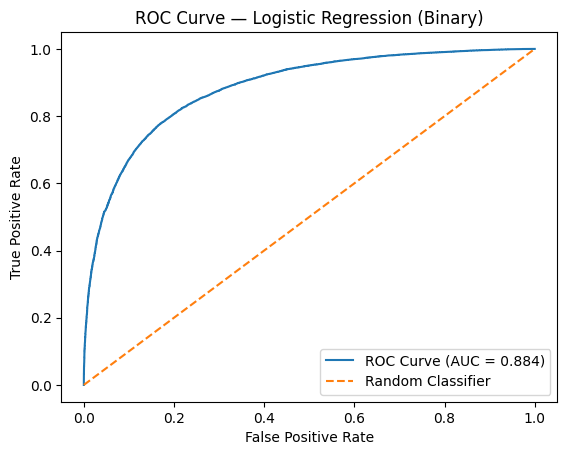

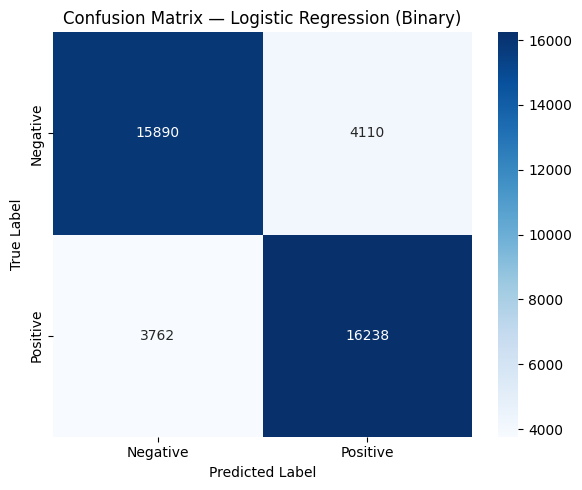

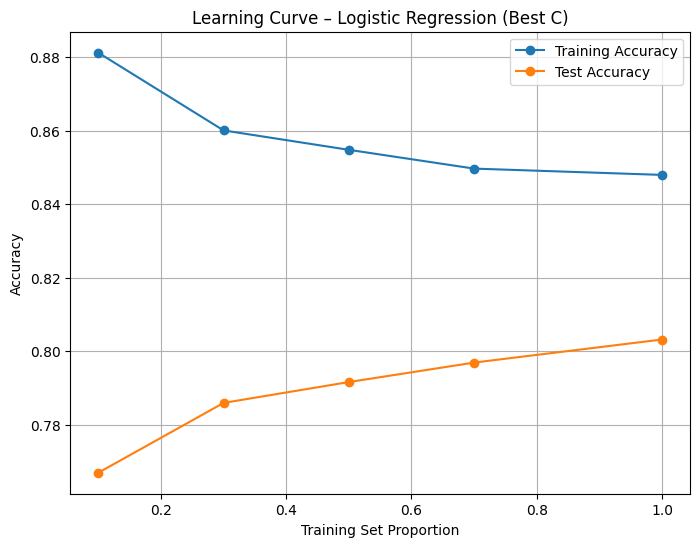

In [ ]:
# ---------- Final evaluation on test set ----------
y_best = best_model.predict(X_test_vec)

test_acc = accuracy_score(y_test, y_best)
test_macro_f1 = f1_score(y_test, y_best, average="macro")

print("\n" + "=" * 60)
print("FINAL TEST RESULTS — Best Logistic Regression Model")
print("=" * 60)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Macro-F1 : {test_macro_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_best, digits=4))

# ===== ROC Curve =====
y_prob = best_model.predict_proba(X_test_vec)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression (Binary)")
plt.legend(loc="lower right")
plt.show()

# ===== Confusion Matrix =====
cm = confusion_matrix(y_test, y_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Logistic Regression (Binary)")
plt.tight_layout()
plt.show()



# ===== Learning Curve =====

train_sizes = [0.1, 0.3, 0.5, 0.7, 1.0]
train_acc = []
test_acc = []

for size in train_sizes:
    n_samples = int(size * X_train_vec.shape[0])

    lr_temp = LogisticRegression(
        solver="saga",
        penalty="l2",
        C=best_C,
        max_iter=2000,
        n_jobs=-1,
        random_state=42
    )

    lr_temp.fit(X_train_vec[:n_samples], y_train[:n_samples])

    train_acc.append(
        accuracy_score(y_train[:n_samples], lr_temp.predict(X_train_vec[:n_samples]))
    )
    test_acc.append(
        accuracy_score(y_test, lr_temp.predict(X_test_vec))
    )

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_acc, label="Training Accuracy", marker='o')
plt.plot(train_sizes, test_acc, label="Test Accuracy", marker='o')
plt.xlabel("Training Set Proportion")
plt.ylabel("Accuracy")
plt.title("Learning Curve – Logistic Regression (Best C)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ============================================
# SVC
# ============================================

# ============================================
# MODEL FINE-TUNING – REGULARIZATION (C) TUNING WITH GRIDSEARCH
# ============================================
C_values = [0.01, 0.1, 1, 10, 100]
param_grid = {'C': C_values}

svm_base = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)

grid_search = GridSearchCV(
    svm_base,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_vec, y_train)

best_C = grid_search.best_params_['C']
best_svm = grid_search.best_estimator_

print(f"Best hyperparameter C = {best_C}")
print(f"Best CV Macro F1 = {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best hyperparameter C = 0.1
Best CV Macro F1 = 0.8005


              precision    recall  f1-score   support

    Negative     0.8104    0.7935    0.8019     20000
    Positive     0.7978    0.8144    0.8060     20000

    accuracy                         0.8040     40000
   macro avg     0.8041    0.8039    0.8039     40000
weighted avg     0.8041    0.8040    0.8039     40000



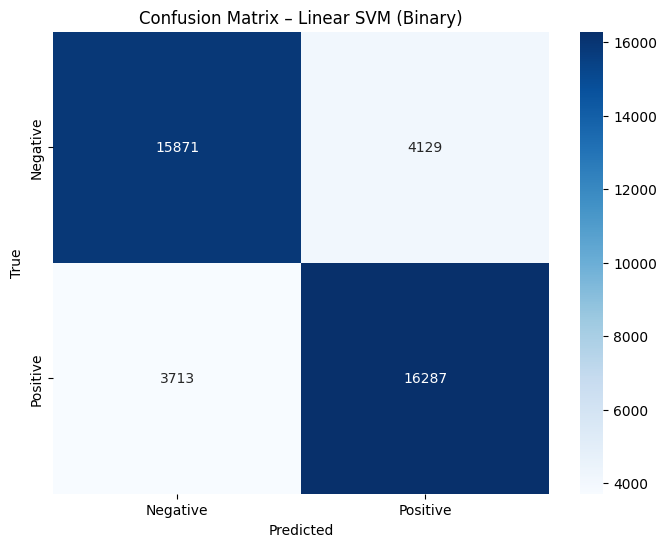

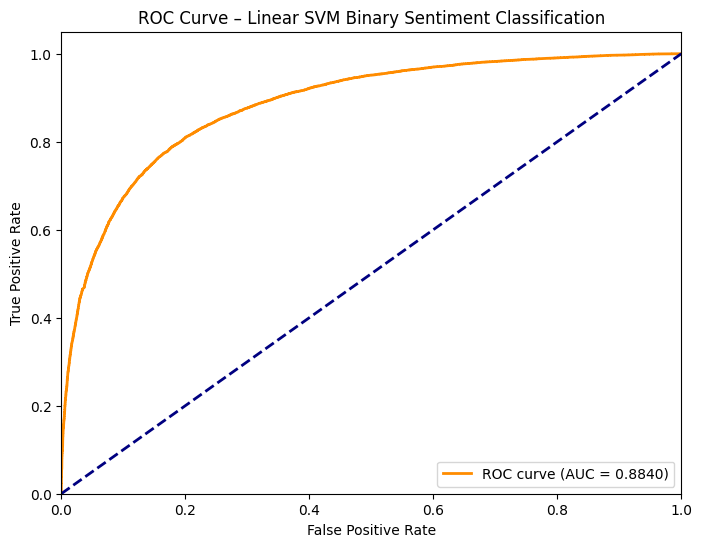

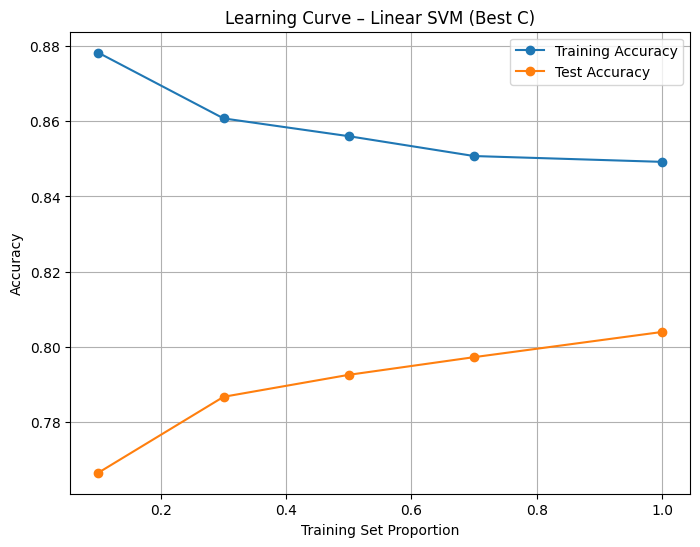

In [ ]:
# ============================================
# EVALUATION ON TEST SET
# ============================================
y_pred = best_svm.predict(X_test_vec)
y_prob = best_svm.decision_function(X_test_vec)  # For ROC

print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"], digits=4))

# ============================================
# CONFUSION MATRIX (VISUAL)
# ============================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.title("Confusion Matrix – Linear SVM (Binary)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ============================================
# ROC CURVE
# ============================================
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Linear SVM Binary Sentiment Classification')
plt.legend(loc="lower right")
plt.show()


# ============================================
# LEARNING CURVE (TRAINING PROGRESS VIA DIFFERENT SIZES)
# ============================================
train_sizes = [0.1, 0.3, 0.5, 0.7, 1.0]
train_acc = []
test_acc = []

for size in train_sizes:
    n_samples = int(size * X_train_vec.shape[0])
    svm_temp = LinearSVC(C=best_C, class_weight='balanced', random_state=42, max_iter=2000)
    svm_temp.fit(X_train_vec[:n_samples], y_train[:n_samples])
    train_acc.append(accuracy_score(y_train[:n_samples], svm_temp.predict(X_train_vec[:n_samples])))
    test_acc.append(accuracy_score(y_test, svm_temp.predict(X_test_vec)))

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_acc, label="Training Accuracy", marker='o')
plt.plot(train_sizes, test_acc, label="Test Accuracy", marker='o')
plt.xlabel("Training Set Proportion")
plt.ylabel("Accuracy")
plt.title("Learning Curve – Linear SVM (Best C)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================
# FFN
# ============================================

# ============================================
# TOKENIZATION & PADDING
# ============================================

MAX_VOCAB = 20000
MAX_LEN = 40

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_train),
    maxlen=MAX_LEN,
    padding="post"
)
X_test_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=MAX_LEN,
    padding="post"
)

X_train_pad = X_train_pad.astype("int32")
X_test_pad  = X_test_pad.astype("int32")

# ============================================
# TRAIN / VALIDATION SPLIT
# ============================================

X_train_pad, X_val_pad, y_train_fnn, y_val = train_test_split(
    X_train_pad,
    y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

y_train_fnn = np.array(y_train_fnn)
y_val = np.array(y_val)
y_test_np = np.array(y_test)

# ============================================
# LOAD GLOVE TWITTER 100D
# ============================================

embedding_dim = 100
embeddings_index = {}

with open("glove.twitter.27B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vec = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vec

embedding_matrix = np.zeros((MAX_VOCAB, embedding_dim), dtype="float32")
for word, i in tokenizer.word_index.items():
    if i < MAX_VOCAB and word in embeddings_index:
        embedding_matrix[i] = embeddings_index[word]


In [ ]:
# ============================================
# FFN: MANUAL GRID SEARCH (VALIDATION ACC)
# ============================================

hidden_units_list = [32, 64]
dropout_rates = [0.2, 0.3]
learning_rates = [1e-3, 5e-4]
epochs_list = [3, 5]

grid_results = []

for units in hidden_units_list:
    for dropout in dropout_rates:
        for lr in learning_rates:
            for epochs in epochs_list:

                model = Sequential([
                    Embedding(
                        input_dim=MAX_VOCAB,
                        output_dim=embedding_dim,
                        weights=[embedding_matrix],
                        trainable=False
                    ),
                    GlobalAveragePooling1D(),
                    Dense(units, activation="relu"),
                    Dropout(dropout),
                    Dense(1, activation="sigmoid")
                ])

                model.compile(
                    optimizer=Adam(learning_rate=lr),
                    loss="binary_crossentropy",
                    metrics=["accuracy"]
                )

                model.fit(
                    X_train_pad,
                    y_train_fnn,
                    epochs=epochs,
                    batch_size=128,
                    verbose=0
                )

                y_val_prob = model.predict(X_val_pad, verbose=0).flatten()
                y_val_pred = (y_val_prob > 0.5).astype(int)
                val_acc = (y_val_pred == y_val).mean()

                grid_results.append({
                    "units": units,
                    "dropout": dropout,
                    "learning_rate": lr,
                    "epochs": epochs,
                    "val_accuracy": val_acc
                })

best_config = max(grid_results, key=lambda x: x["val_accuracy"])
print("Best FFN Configuration (Validation):", best_config)

final_model = Sequential([
    Embedding(
        input_dim=MAX_VOCAB,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    ),
    GlobalAveragePooling1D(),
    Dense(best_config["units"], activation="relu"),
    Dropout(best_config["dropout"]),
    Dense(1, activation="sigmoid")
])

final_model.compile(
    optimizer=Adam(learning_rate=best_config["learning_rate"]),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = final_model.fit(
    X_train_pad,
    y_train_fnn,
    validation_data=(X_val_pad, y_val),
    epochs=best_config["epochs"],
    batch_size=128,
    verbose=1
)

Best FFN Configuration (Validation): {'units': 64, 'dropout': 0.2, 'learning_rate': 0.001, 'epochs': 5, 'val_accuracy': np.float64(0.754625)}
Epoch 1/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6833 - loss: 0.5957 - val_accuracy: 0.7443 - val_loss: 0.5189
Epoch 2/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7448 - loss: 0.5157 - val_accuracy: 0.7485 - val_loss: 0.5089
Epoch 3/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7497 - loss: 0.5070 - val_accuracy: 0.7501 - val_loss: 0.5045
Epoch 4/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7527 - loss: 0.5033 - val_accuracy: 0.7533 - val_loss: 0.5013
Epoch 5/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7556 - loss: 0.4996 - val_accuracy: 0.7553 - val_loss: 0.4981


              precision    recall  f1-score   support

    Negative       0.73      0.79      0.76     20000
    Positive       0.77      0.71      0.74     20000

    accuracy                           0.75     40000
   macro avg       0.75      0.75      0.75     40000
weighted avg       0.75      0.75      0.75     40000



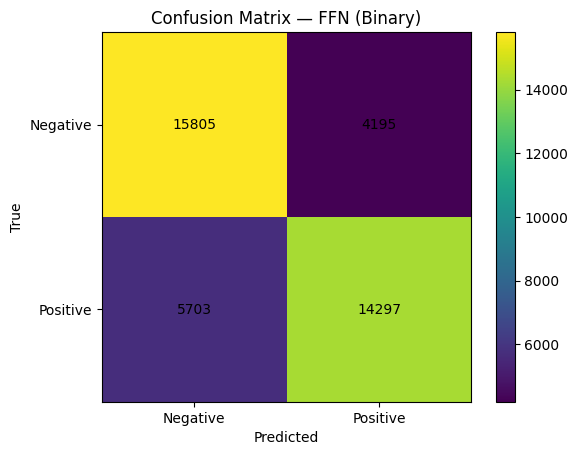

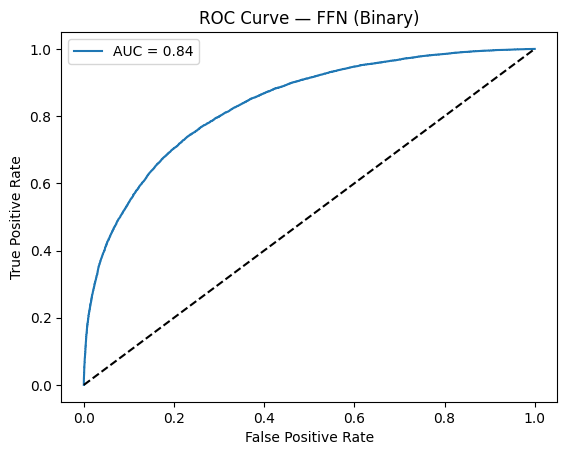

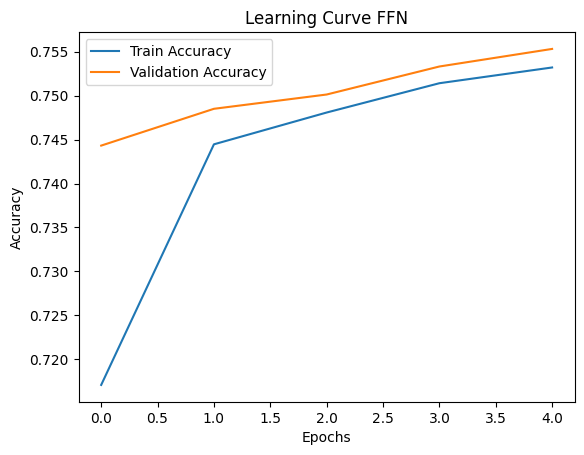

In [ ]:
# ============================================
# FFN: FINAL EVALUATION ON TEST
# ============================================

y_test_prob = final_model.predict(X_test_pad, verbose=0).flatten()
y_test_pred = (y_test_prob > 0.5).astype(int)

print(classification_report(
    y_test_np,
    y_test_pred,
    target_names=["Negative", "Positive"]
))

# Confusion matrix
cm = confusion_matrix(y_test_np, y_test_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix — FFN (Binary)")
plt.colorbar()
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test_np, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — FFN (Binary)")
plt.legend()
plt.show()

# Learning Curve (epochs)
plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Learning Curve FFN")
plt.legend()
plt.show()

In [ ]:
# Insights and Conclusions
# - Interpret model outputs and feature importance


# ===== FEATURE IMPORTANCE: Logistic Regression =====
feature_names = vectorizer.get_feature_names_out()
coef = best_model.coef_[0]

top_pos = np.argsort(coef)[-10:][::-1]
top_neg = np.argsort(coef)[:10]

print("\n[LR] Top Positive features:")
for i in top_pos:
    print(f"{feature_names[i]}: {coef[i]:.4f}")

print("\n[LR] Top Negative features:")
for i in top_neg:
    print(f"{feature_names[i]}: {coef[i]:.4f}")

# ===== FEATURE IMPORTANCE: Linear SVM =====
feature_names = vectorizer.get_feature_names_out()
coef = best_svm.coef_[0]

top_pos = np.argsort(coef)[-10:][::-1]
top_neg = np.argsort(coef)[:10]

print("\n[SVM] Top Positive features:")
for i in top_pos:
    print(f"{feature_names[i]}: {coef[i]:.4f}")

print("\n[SVM] Top Negative features:")
for i in top_neg:
    print(f"{feature_names[i]}: {coef[i]:.4f}")



# ===== FFN TOKEN IMPORTANCE (OCCLUSION) =====

index_word = {v:k for k,v in tokenizer.word_index.items()}

def seq_to_tokens(seq):
    # seq is length MAX_LEN with ints
    toks = []
    for idx in seq:
        if idx == 0:
            continue
        toks.append(index_word.get(idx, "<OOV>"))
    return toks

# ===== occlusion importance for ONE tweet
def occlusion_importance_ffn(model, seq, baseline_prob=None):
    """
    seq: 1D int array length MAX_LEN
    returns list of (token, delta) where delta = baseline_prob - prob_when_token_removed
    positive delta => token was supporting POSITIVE prediction
    negative delta => token was supporting NEGATIVE prediction
    """
    x = np.array([seq], dtype="int32")
    if baseline_prob is None:
        baseline_prob = float(model.predict(x, verbose=0).flatten()[0])

    toks = seq_to_tokens(seq)
    importances = []

    for pos in range(len(seq)):
        if seq[pos] == 0:
            continue
        x_mask = x.copy()
        x_mask[0, pos] = 0  # remove token by setting to PAD=0
        prob_mask = float(model.predict(x_mask, verbose=0).flatten()[0])
        delta = baseline_prob - prob_mask
        importances.append((pos, delta))

    return baseline_prob, toks, importances


# Run on a few test examples and print top tokens
np.random.seed(42)
sample_ids = np.random.choice(len(X_test_pad), size=5, replace=False)

for idx in sample_ids:
    seq = X_test_pad[idx]
    base_p, toks, imps = occlusion_importance_ffn(final_model, seq)

    # map position->token
    pos_to_tok = {i: index_word.get(seq[i], "<OOV>") for i,_ in imps}

    # top tokens pushing positive / negative
    imps_sorted = sorted(imps, key=lambda x: x[1], reverse=True)

    top_pos = [(pos_to_tok[p], d) for p,d in imps_sorted[:8]]
    top_neg = [(pos_to_tok[p], d) for p,d in imps_sorted[-8:]]

    print("\n==============================")
    print("Tweet tokens:", toks[:25])
    print(f"FFN P(positive) = {base_p:.3f}")

    print("\nTop tokens supporting POSITIVE (remove => prob drops):")
    for w,d in top_pos:
        print(f"{w:>12}: {d:+.4f}")

    print("\nTop tokens supporting NEGATIVE (remove => prob rises):")
    for w,d in reversed(top_neg):
        print(f"{w:>12}: {d:+.4f}")



[LR] Top Positive features:
thanks: 5.9052
awesome: 5.3394
not bad: 5.2800
happy: 5.2443
cant wait: 5.1500
love: 5.0775
yay: 4.6242
no problem: 4.4747
great: 4.3764
welcome: 4.3656

[LR] Top Negative features:
sad: -13.3727
miss: -9.2084
poor: -7.5484
sick: -7.4134
missing: -7.1484
wish: -6.8352
sucks: -6.8006
sorry: -6.7668
hate: -6.7486
not: -6.2760

[SVM] Top Positive features:
not bad: 2.0480
cant wait: 1.9806
thanks: 1.9691
awesome: 1.8374
happy: 1.7897
love: 1.7499
no problem: 1.7436
yay: 1.6518
excited: 1.5436
good: 1.5398

[SVM] Top Negative features:
sad: -4.5830
miss: -3.3130
poor: -2.7614
missing: -2.6075
sick: -2.5723
wish: -2.5099
sorry: -2.5057
sucks: -2.4025
not: -2.3937
hate: -2.3673

Tweet tokens: ['its', '<OOV>', 'quiet', 'missing', 'my', 'son', 'like', 'mad']
FFN P(positive) = 0.087

Top tokens supporting POSITIVE (remove => prob drops):
         its: +0.0242
       quiet: +0.0206
        like: +0.0158
       <OOV>: +0.0000
          my: -0.0058
         son: -0.006

In [ ]:
# ============================================
# ERROR ANALYSIS ACROSS MODELS
# ============================================

yy_lr_pred  = best_model.predict(X_test_vec)
y_svm_pred = best_svm.predict(X_test_vec)

y_fnn_prob = final_model.predict(X_test_pad, verbose=0).flatten()
y_fnn_pred = (y_fnn_prob > 0.5).astype(int)

# ensure numpy arrays
y_test_np = np.array(y_test)

def error_df(model_name, X_text, y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return pd.DataFrame({
        "model": model_name,
        "text": X_text.reset_index(drop=True),
        "y_true": y_true,
        "y_pred": y_pred,
        "is_error": (y_true != y_pred)
    })

all_err = pd.concat([
    error_df("Logistic Regression", X_test, y_test_np, y_lr_pred),
    error_df("SVM",                X_test, y_test_np, y_svm_pred),
    error_df("FFN",                X_test, y_test_np, y_fnn_pred),
], ignore_index=True)

print("\nError rate per model:")
print(all_err.groupby("model")["is_error"].mean())

# --- simple error categories ---
def tag_negation(t):
    return bool(re.search(r"\b(not|n't|never|no)\b", str(t).lower()))

def tag_emoji(t):
    return bool(re.search(r"(:\)|:-\)|:\(|:-\(|<3)", str(t).lower()))

def tag_short(t):
    return len(re.findall(r"\w+", str(t))) <= 3

all_err["negation"] = all_err["text"].apply(tag_negation)
all_err["emoji"]    = all_err["text"].apply(tag_emoji)
all_err["short"]    = all_err["text"].apply(tag_short)

for cat in ["negation", "emoji", "short"]:
    tmp = all_err[all_err[cat]]
    print(f"\nError rates for tweets with {cat}:")
    print(tmp.groupby("model")["is_error"].mean())


Error rate per model:
model
FFN                    0.24745
Logistic Regression    0.19680
SVM                    0.19605
Name: is_error, dtype: float64

Error rates for tweets with negation:
model
FFN                    0.290385
Logistic Regression    0.238848
SVM                    0.237982
Name: is_error, dtype: float64

Error rates for tweets with emoji:
Series([], Name: is_error, dtype: float64)

Error rates for tweets with short:
model
FFN                    0.167671
Logistic Regression    0.150602
SVM                    0.150100
Name: is_error, dtype: float64
